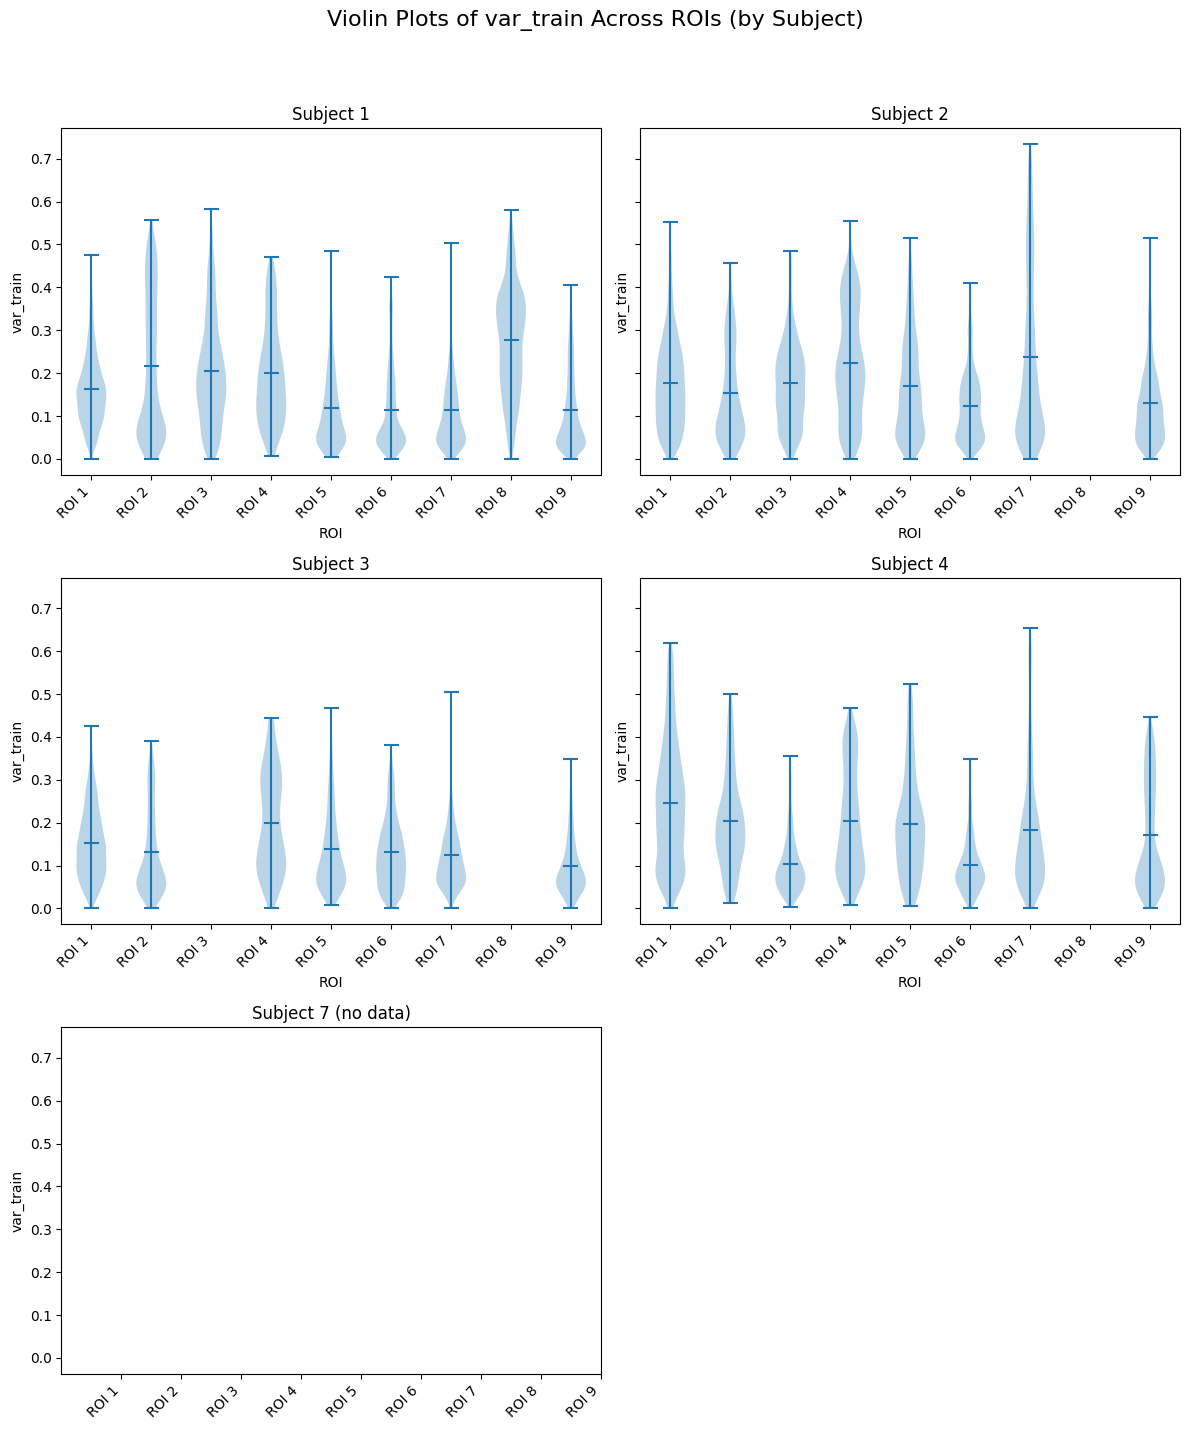

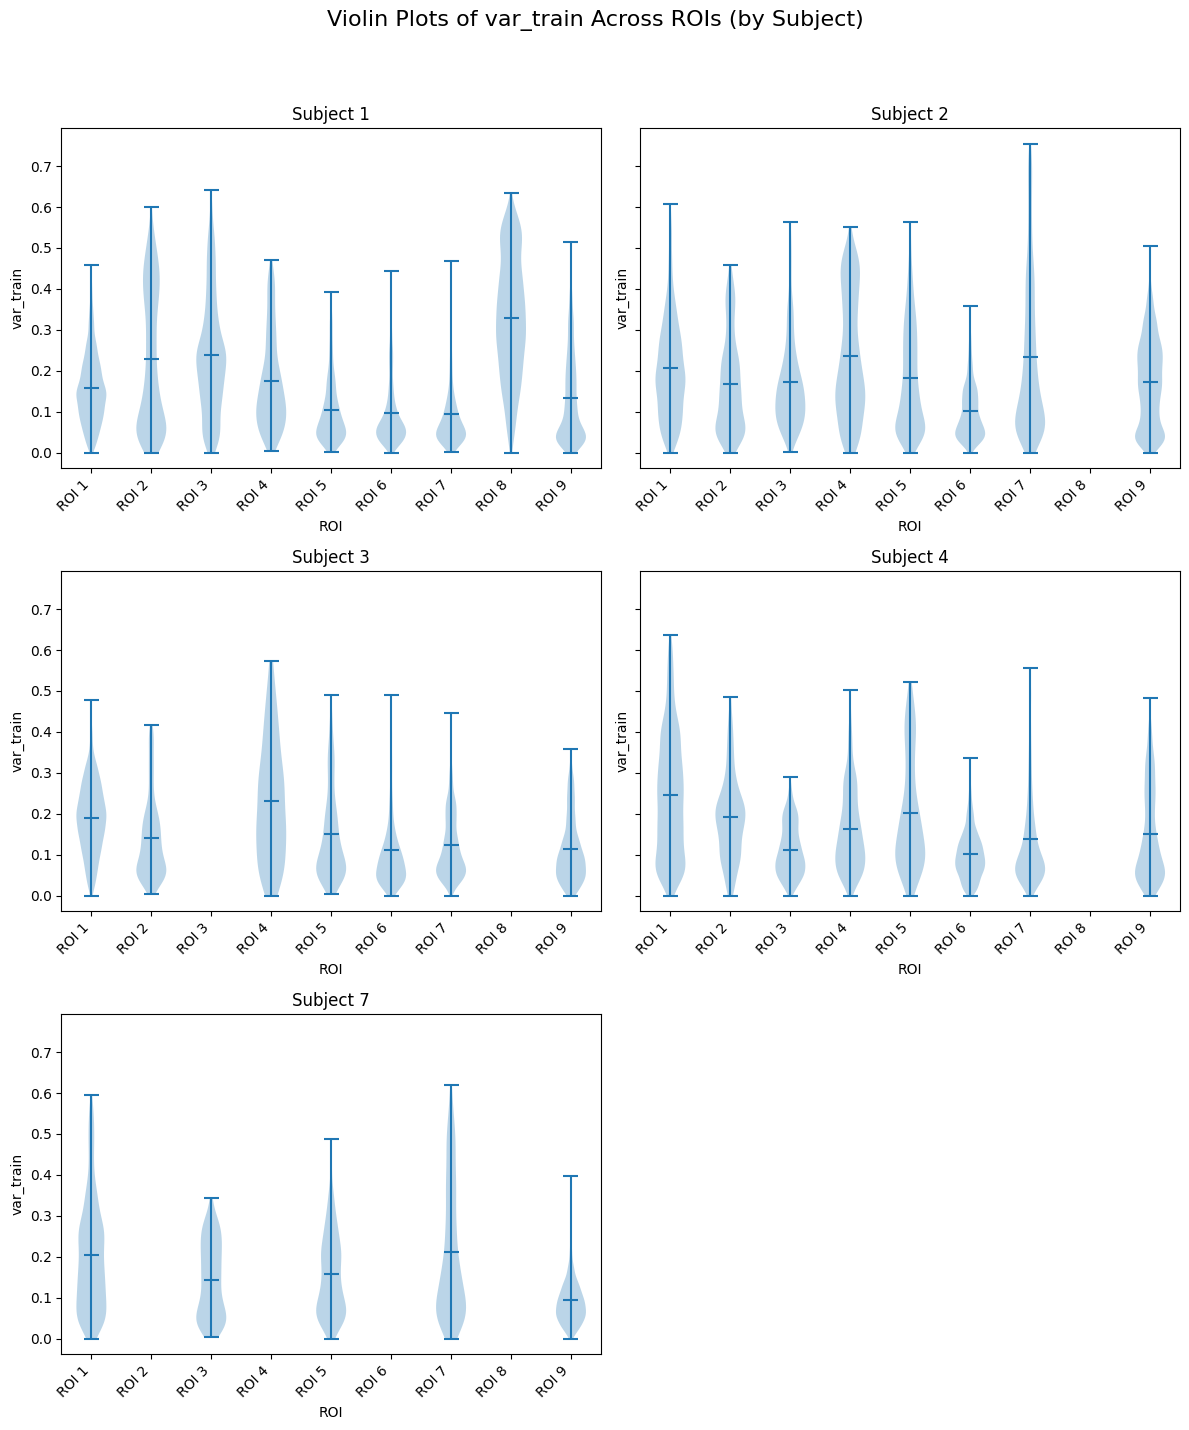

In [2]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt

def _load_column_data_for_subject_positions(column_name, roi_nums, base_path, file_template, shared_mds:bool=True):
    """
    For a given subject directory, attempt to load `column_name` from each ROI file.
    Returns a tuple (data_list, positions, labels) where:
      - data_list is a list of pandas.Series for ROIs that exist,
      - positions is a list of integer x‐positions (matching the ROI numbers) for those series,
      - labels is a list of strings "ROI {roi}" for all roi_nums (used for xticks).
    """
    data_list = []
    positions = []
    labels = [f"ROI {roi}" for roi in roi_nums]

    for roi in roi_nums:
        path = os.path.join(base_path, file_template.format(roi=roi))
        if os.path.isfile(path):
            df = pd.read_excel(path)

            try:
                if shared_mds:
                    df = df[df["mds_hemi"] == "both"]
                else:
                    df = df[df["mds_hemi"] != "both"]

            except:
                pass



            if column_name in df.columns:
                data_list.append(df[column_name])
                positions.append(roi)
            else:
                print(f"Warning: Column '{column_name}' not in {path}; leaving ROI {roi} empty.")
        else:
            print(f"Warning: File not found for ROI {roi}: {path}; leaving ROI {roi} empty.")

    return data_list, positions, labels

def plot_violins_across_subjects(
    column_name,
    subjects,
    roi_nums=range(1, 10),
    base_dir_template='data/gaussian_results/subj_{subj:02d}/subj{subj:02d}',
    file_template='fitted_voxels_mask_{roi}.xlsx',
    shared_mds: bool = True
):
    """
    For each subject in `subjects`, reads `column_name` from each ROI file
    (filling missing ROIs with whitespace) and plots all violin plots in a grid
    (max 2 plots per row). Missing ROIs leave blank space at their x‐positions.

    Parameters
    ----------
    column_name : str
        Name of the column to visualize (e.g. 'var_train', 'var_test', 'sigma', etc.)
    subjects : iterable of int
        List of subject numbers (e.g. [1, 2, 3, 4])
    roi_nums : iterable of int
        ROI numbers to include for each subject (default 1–9)
    base_dir_template : str
        Template for the subject directory; must contain '{subj}' placeholder, e.g.
        'data/gaussian_results/subj_{subj:02d}/subj{subj:02d}'
    file_template : str
        Template for the filenames in each subject directory; must include '{roi}'.

    Raises
    ------
    FileNotFoundError
        If none of the specified files are found for any subject.
    """
    n_subj = len(subjects)
    if n_subj == 0:
        raise ValueError("Please provide at least one subject number.")

    # Determine grid layout: max 2 columns per row
    n_cols = min(2, n_subj)
    n_rows = math.ceil(n_subj / 2)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True)
    # Flatten axes so we can zip easily; handle case n_subj=1
    if isinstance(axes, plt.Axes):
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    any_data_loaded = False

    for ax, subj in zip(axes_flat, subjects):
        base_path = base_dir_template.format(subj=subj)
        data_list, positions, labels = _load_column_data_for_subject_positions(
            column_name, roi_nums, base_path, file_template, shared_mds=shared_mds
        )

        if not data_list:
            # No data loaded for any ROI of this subject
            print(f"Warning: No data loaded for subject {subj}; leaving subplot blank.")
            ax.set_title(f"Subject {subj} (no data)")
            ax.set_xticks(list(roi_nums))
            ax.set_xticklabels(labels, rotation=45, ha='right')
            ax.set_ylabel(column_name)
            continue

        any_data_loaded = True
        # Plot violins only at the ROIs that have data, but leave x-axis ticks for all
        ax.violinplot(data_list, positions=positions, showmeans=True)
        ax.set_xticks(list(roi_nums))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_xlim(min(roi_nums) - 0.5, max(roi_nums) + 0.5)  # ensure whitespace for missing at edges
        ax.set_title(f"Subject {subj}")
        ax.set_xlabel("ROI")
        ax.set_ylabel(column_name)

    # Hide any unused subplots
    for extra_ax in axes_flat[n_subj:]:
        extra_ax.set_visible(False)

    if not any_data_loaded:
        raise FileNotFoundError("No valid data loaded for any subject; check paths and column name.")

    fig.suptitle(f"Violin Plots of {column_name} Across ROIs (by Subject)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# Example usage:
plot_violins_across_subjects('var_train', subjects=[1, 2, 3, 4])
plot_violins_across_subjects("var_train", subjects=[1,2,3,4], base_dir_template='data/gaussian_results/backup/subj_{subj:02d}/subj{subj:02d}')

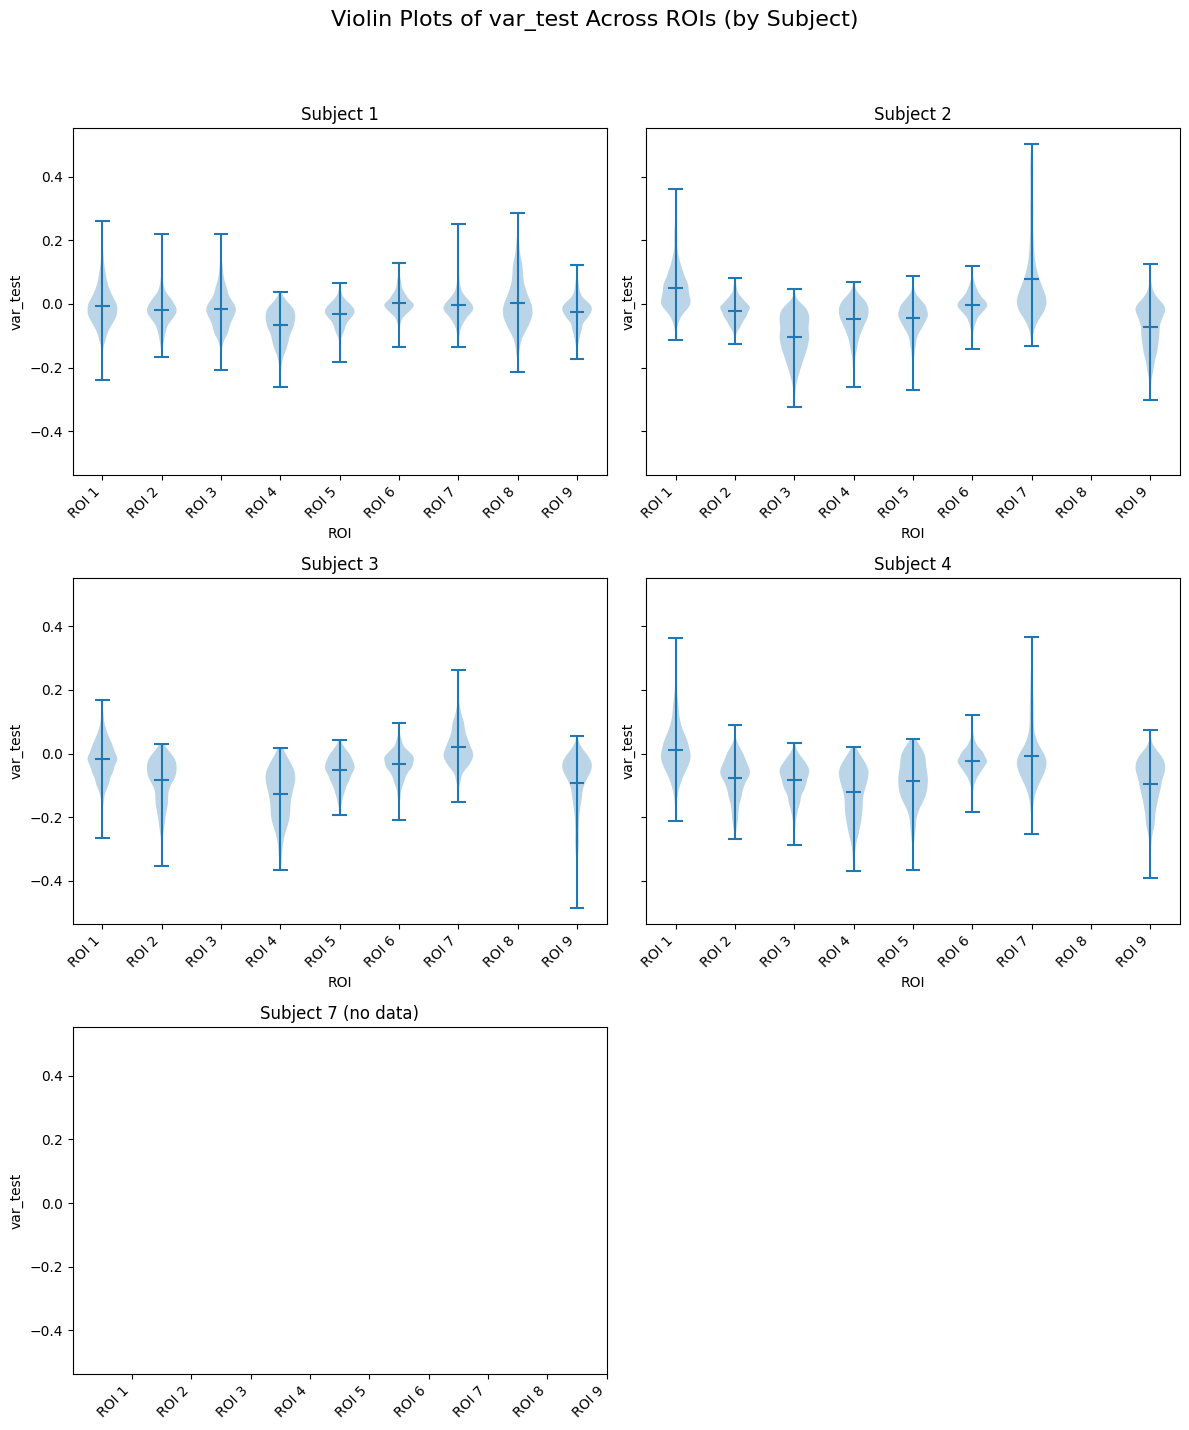

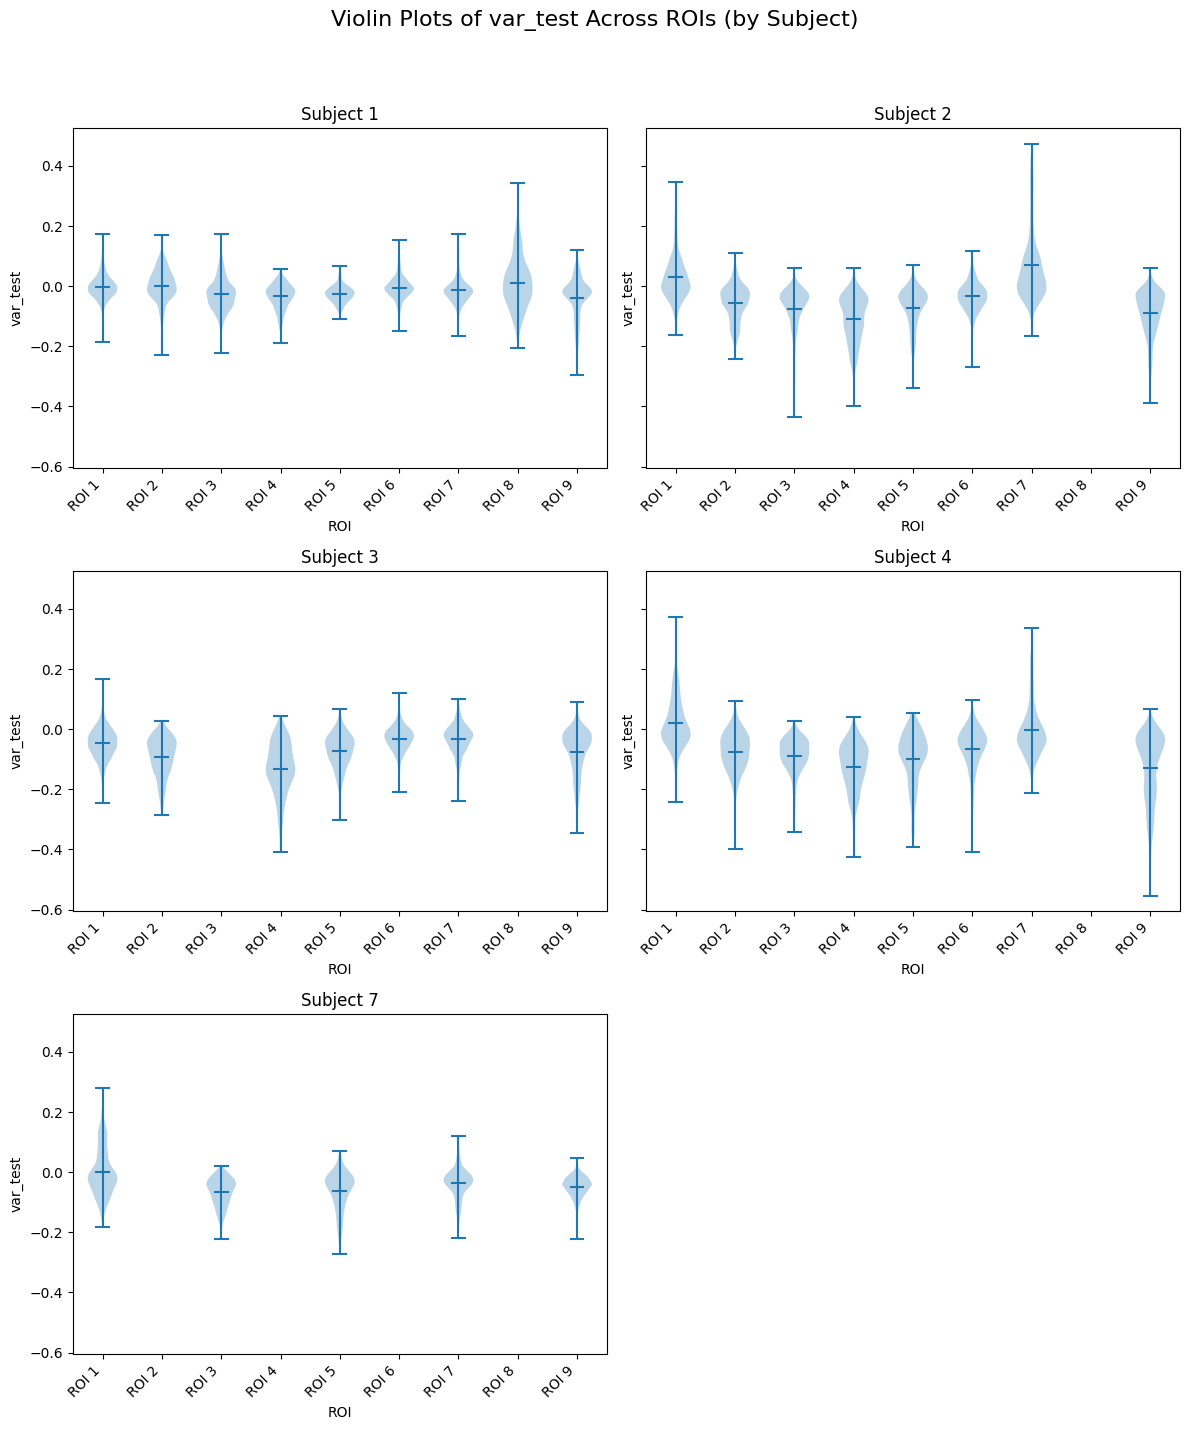

In [3]:
plot_violins_across_subjects('var_test', subjects=[1, 2, 3, 4, 7])
plot_violins_across_subjects("var_test", subjects=[1,2,3,4,7], base_dir_template='data/gaussian_results/backup/subj_{subj:02d}/subj{subj:02d}')
